<div align="center">

<h2>📊 AtliQ Hotels - Data Analysis and Business Insights</h2>

<p><b>🎯 Goal:</b><br>
Analyze hotel booking data to identify revenue leakage, customer behavior, demand trends, and provide business recommendations to improve profitability.
</p>

</div>

###  importing libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 📂 Data Loading

In [21]:
df = pd.read_csv("data/final_dataset.csv", low_memory=False)
df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,day_type,week no,mmm yy,room_class
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,Standard
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,Standard
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,Standard
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,Standard
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,Standard


### 🧹 Data Cleaning & Preprocessing

- Converted date columns into proper datetime format while handling inconsistent formats  
- Used `errors='coerce'` to safely manage invalid or corrupt date entries  
- Removed duplicate records to maintain data integrity  
- Identified missing values across columns for further handling and analysis

In [22]:
import warnings
warnings.filterwarnings('ignore')

df['check_in_date'] = pd.to_datetime(df['check_in_date'], errors='coerce', dayfirst=True)
df['checkout_date'] = pd.to_datetime(df['checkout_date'], errors='coerce', dayfirst=True)
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce', dayfirst=True)

### 🧹 Missing Values Summary

- Missing values were observed in:
  - check_in_date
  - checkout_date
  - ratings_given

- These were handled appropriately depending on context:
  - Date columns were converted using `pd.to_datetime()`
  - Missing ratings were retained as they represent unrated bookings

In [23]:
# Create missing values table
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Values']
missing = missing[missing['Missing Values'] > 0]

missing

,Column,Missing Values
3,check_in_date,78783
4,checkout_date,79932
7,ratings_given,77897
14,day_type,55790
15,week no,55790
16,mmm yy,55790


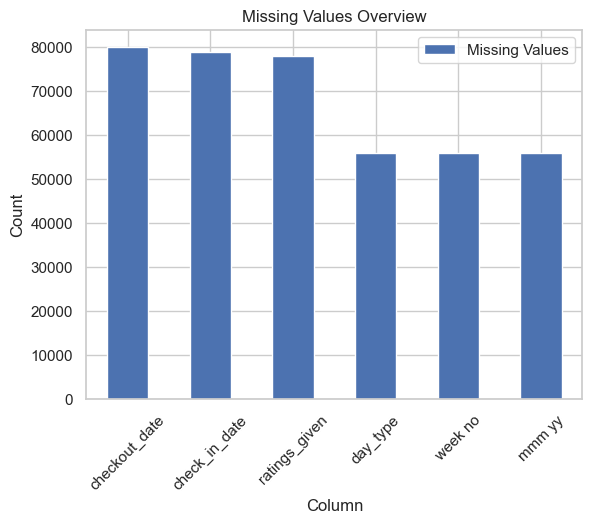

In [24]:
missing.sort_values(by='Missing Values', ascending=False)\
       .plot(kind='bar', x='Column')

plt.title("Missing Values Overview")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## ⚙️ Feature Engineering

Creating meaningful features to uncover hidden patterns and enhance analytical depth in booking data.

In [25]:
df['month'] = df['booking_date'].dt.month

df['day_type'] = df['check_in_date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

 ### 🔍 Why Feature Engineering ? 

- **month** enables identification of seasonality patterns, helping uncover peak demand periods, off-season trends, and recurring booking cycles across the year.

- **day_type** helps analyze behavioral differences between weekday and weekend bookings, providing insights into customer travel patterns, leisure vs business demand, and occupancy variations.

- These engineered features enhance overall analysis by supporting **trend identification, demand forecasting, and dynamic pricing strategies**, ultimately enabling more data-driven business decisions.

### 📌 Data Overview

- Total Records: **7.3 Million**
- Total Columns: **19**
- Dataset contains booking, revenue, customer behavior, and property details.

#### Key Columns:
- Booking Details → booking_id, booking_date, check_in_date, checkout_date  
- Customer Info → no_guests, ratings_given  
- Business Metrics → revenue_generated, revenue_realized  
- Segmentation → city, room_category, booking_platform  

> The dataset is large-scale and suitable for analyzing booking trends, revenue patterns, and customer behavior.

### 🧠 Dataset Understanding

This dataset represents booking-level transactions across multiple properties and cities.  
Each row corresponds to a single booking, capturing revenue, platform, and customer behavior.

The data enables analysis of:
- Revenue leakage (cancelled / no-show bookings)
- Platform performance
- Property and city-level trends

## 📊 Exploratory Data Analysis (EDA) & Business Insights  
In this section, we dive deep into booking data to uncover hidden patterns, identify revenue leakage, analyze customer behavior, and derive actionable insights that can help optimize pricing, improve occupancy, and enhance customer experience.

 ### 📌 Insight 1: Booking Status Distribution  

Understanding the distribution of booking statuses is critical to identifying operational inefficiencies and revenue leakage. A high proportion of cancellations or no-shows directly impacts realized revenue and occupancy rates.

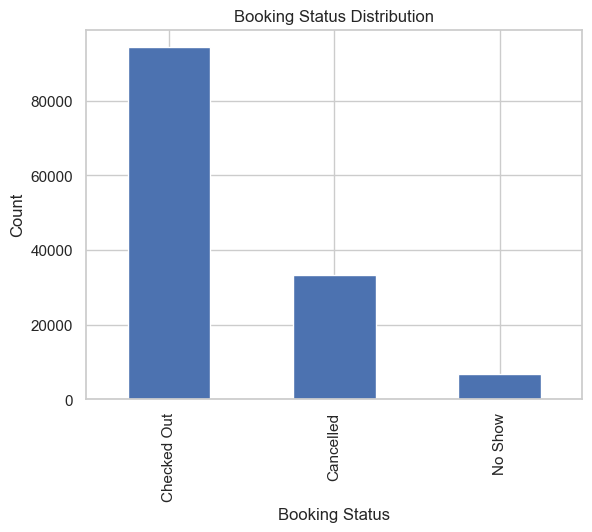

In [26]:
df['booking_status'].value_counts().plot(kind='bar')
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()

📊 Observation:  
A significant share of bookings fall under cancelled and no-show categories compared to successful bookings.

💡 Insight:  
This indicates substantial revenue leakage, as potential revenue from these bookings is not realized. It also highlights inefficiencies in booking confirmation and customer commitment.

🚀 Recommendation:  
Introduce stricter cancellation policies, implement partial advance payments, and use reminder systems to reduce no-shows and improve booking conversion rates.

### 📌 Insight 2: Revenue Leakage Analysis  

Analyzing the gap between revenue generated and revenue realized helps quantify the financial impact of cancellations and no-shows. This is crucial for understanding lost revenue opportunities.

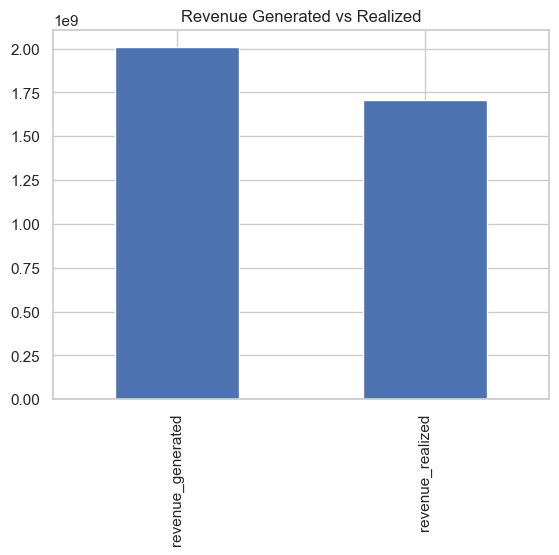

In [27]:
df[['revenue_generated', 'revenue_realized']].sum().plot(kind='bar')
plt.title("Revenue Generated vs Realized")
plt.show()

📊 Observation:  
Total revenue generated is significantly higher than the revenue actually realized.

💡 Insight:  
This gap represents revenue leakage caused by cancellations and no-shows. Even though bookings are made, a portion of expected revenue is never realized, leading to financial inefficiencies.

🚀 Recommendation:  
Implement strategies such as non-refundable bookings, partial upfront payments, and stricter cancellation policies to minimize revenue loss. Additionally, predictive models can be used to identify high-risk bookings and take preventive action.

### 📌 Insight 2: Revenue Leakage Analysis  

Analyzing the gap between revenue generated and revenue realized helps quantify the financial impact of cancellations and no-shows. This is crucial for understanding lost revenue opportunities.

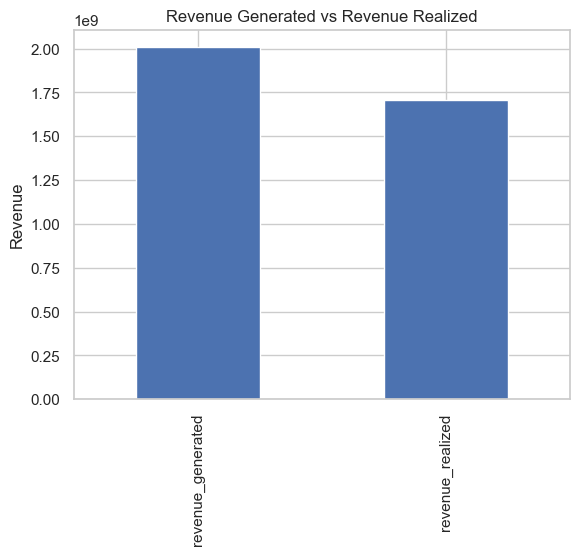

Revenue Leakage: 298748856.00
Revenue Leakage %: 14.88%


In [28]:
df[['revenue_generated', 'revenue_realized']].sum().plot(kind='bar')

plt.title("Revenue Generated vs Revenue Realized")
plt.ylabel("Revenue")
plt.show()

leakage = df['revenue_generated'].sum() - df['revenue_realized'].sum()
leakage_pct = (leakage / df['revenue_generated'].sum()) * 100

print(f"Revenue Leakage: {leakage:.2f}")
print(f"Revenue Leakage %: {leakage_pct:.2f}%")

📊 Observation:  
Total revenue generated is significantly higher than the revenue actually realized.

💡 Insight:  
This gap represents revenue leakage caused by cancellations and no-shows. Even though bookings are made, a portion of expected revenue is never realized, leading to financial inefficiencies.

🚀 Recommendation:  
Implement strategies such as non-refundable bookings, partial upfront payments, and stricter cancellation policies to minimize revenue loss. Additionally, predictive models can be used to identify high-risk bookings and take preventive action.

### 📌 Insight 4: Revenue Contribution by City  

Analyzing revenue distribution across cities helps identify high-performing markets and understand geographic demand patterns. This insight is essential for strategic expansion and targeted marketing.

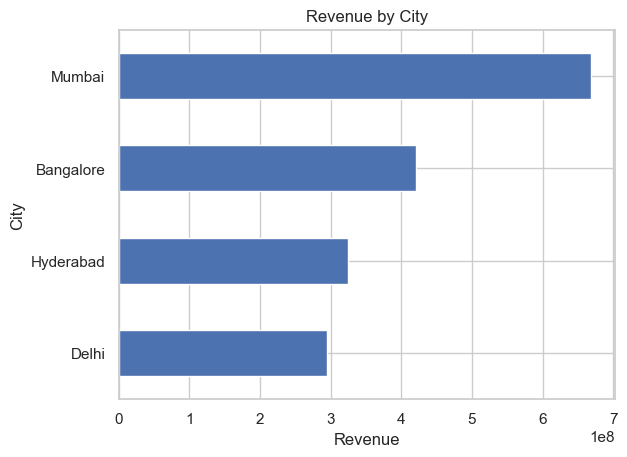

city
Mumbai       668569251
Bangalore    420383550
Hyderabad    325179310
Delhi        294404488
Name: revenue_realized, dtype: int64

In [29]:
df.groupby('city')['revenue_realized']\
  .sum()\
  .sort_values()\
  .plot(kind='barh')

plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.show()
df.groupby('city')['revenue_realized']\
  .sum()\
  .sort_values(ascending=False)\
  .head()

📊 Observation:  
Certain cities contribute significantly higher revenue compared to others, indicating uneven distribution of demand.



💡 Insight:  
This suggests that demand is concentrated in specific locations, possibly due to factors like tourism, business hubs, or better property performance. Lower-performing cities indicate untapped potential or operational inefficiencies.



🚀 Recommendation:  
Focus marketing and promotional efforts on high-performing cities to maximize revenue, while also analyzing underperforming cities to identify growth opportunities. Strategic investments and localized pricing strategies can help improve performance in weaker regions.

### 📌 Insight 5A: Revenue by Hotel Category  

Analyzing revenue across hotel categories provides a high-level view of market positioning and customer segments.

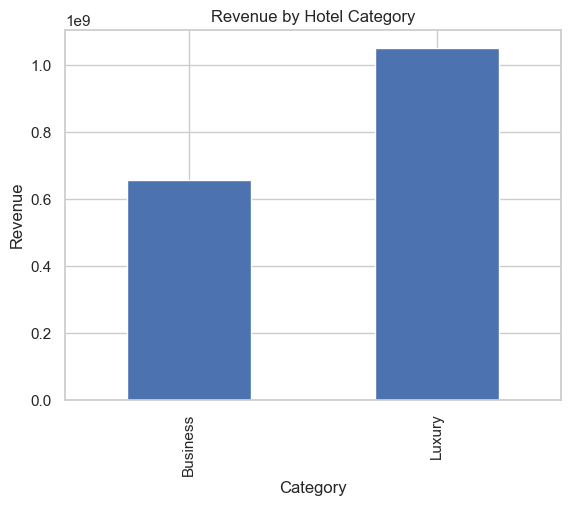

In [30]:
df.groupby('category')['revenue_realized']\
  .sum()\
  .sort_values()\
  .plot(kind='bar')

plt.title("Revenue by Hotel Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

📊 Observation:  
Luxury category contributes significantly higher revenue compared to business category.


 
💡 Insight:  
This indicates that premium offerings drive a major portion of revenue, suggesting strong demand for higher-end experiences.



🚀 Recommendation:  
Focus on enhancing premium services and pricing strategies for luxury segments while improving value propositions in business category to balance demand.

### 📌 Insight 5B: Revenue by Room Class  

A detailed analysis of revenue contribution across different room classes helps understand customer preferences and evaluate the effectiveness of pricing strategies across various service tiers.

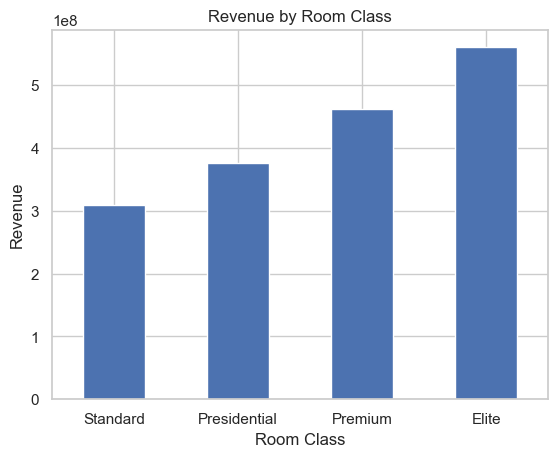

In [31]:
df.groupby('room_class')['revenue_realized']\
  .sum()\
  .sort_values()\
  .plot(kind='bar')

plt.title("Revenue by Room Class")
plt.xlabel("Room Class")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

📊 Observation:  
Revenue contribution increases consistently across room classes, with Elite and Premium categories generating significantly higher revenue compared to Standard and Presidential rooms. The distribution shows a clear upward trend as we move toward higher-tier room classes.

💡 Insight:  
Higher-tier room classes contribute disproportionately to overall revenue, indicating strong customer preference for premium experiences or higher pricing power in these segments. While Standard rooms may drive volume, premium categories act as key revenue drivers, highlighting a value-over-volume dynamic.

🚀 Recommendation:  
Focus on maximizing revenue from premium segments by enhancing luxury offerings, personalized services, and targeted marketing for high-value customers. At the same time, optimize pricing strategies and upselling techniques to encourage customers from lower-tier rooms to upgrade, thereby increasing overall revenue per booking.

### 📌 Insight 6: Weekday vs Weekend Revenue  

Analyzing revenue distribution between weekdays and weekends helps uncover demand patterns, customer intent, and potential revenue optimization opportunities across different time segments.

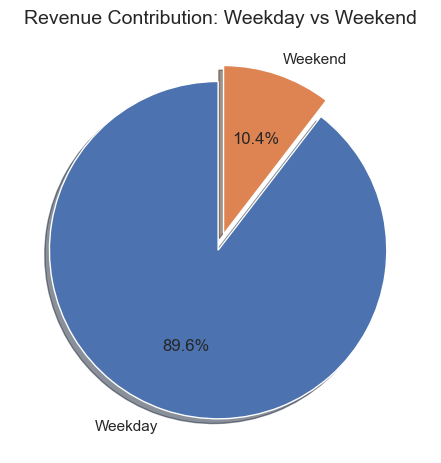

In [32]:
rev = df.groupby('day_type')['revenue_realized'].sum()

rev.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0.05] if len(rev) == 2 else None,
    shadow=True
)

plt.title("Revenue Contribution: Weekday vs Weekend", fontsize=14)
plt.ylabel("")
plt.tight_layout()
plt.show()

 📊 Observation:  
Revenue contribution is overwhelmingly dominated by weekends, with weekdays showing minimal or negligible share in comparison. The distribution appears highly skewed rather than balanced.



 💡 Insight:  
This pattern indicates a strong reliance on leisure-driven demand, where customers predominantly book stays during weekends. The lack of weekday contribution suggests either underutilization of capacity during business days or a missed opportunity in attracting business and mid-week travelers.  

Additionally, such extreme skewness may also point toward a potential data imbalance or filtering issue, which should be validated before drawing final business conclusions.



 🚀 Recommendation:  
To create a more balanced and resilient revenue stream:

- Develop targeted weekday strategies such as corporate tie-ups, business travel packages, and long-stay discounts  
- Introduce dynamic pricing to incentivize mid-week bookings and improve occupancy  
- Launch promotional campaigns focused on weekday experiences (work-from-hotel, staycation offers)  
- Validate dataset distribution to ensure insights reflect actual business performance and not data gaps  

By reducing dependency on weekend spikes, the business can achieve more stable and predictable revenue growth.

### 📌 Insight 7: Booking Trend Over Time  

Analyzing how booking volume evolves over time provides a deeper understanding of demand cycles, seasonality patterns, and potential external influences affecting customer behavior.

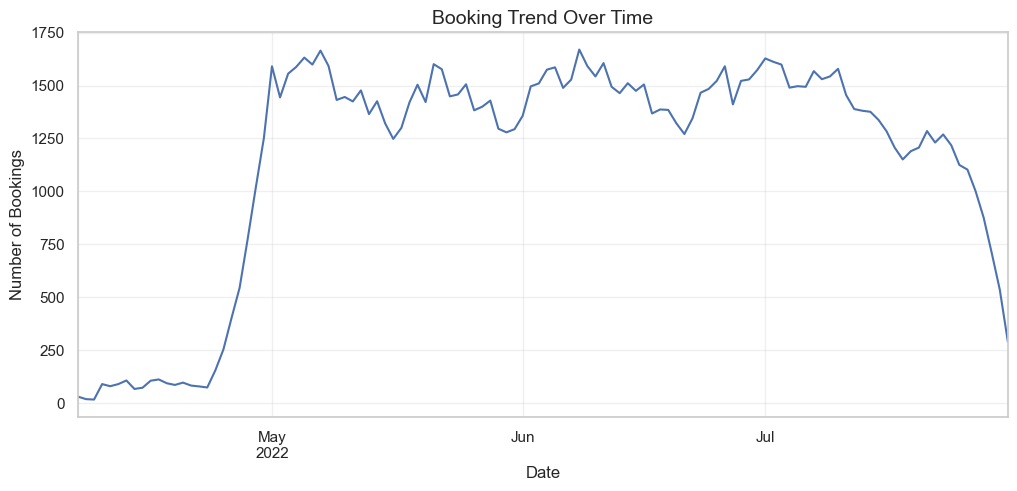

In [33]:
import warnings
warnings.filterwarnings('ignore')
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')

# Grouping data
booking_trend = df.groupby('booking_date')['booking_id'].count()

# Ploting trend
plt.figure(figsize=(12,5))
booking_trend.plot()

plt.title("Booking Trend Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Bookings")
plt.grid(alpha=0.3)

plt.show()

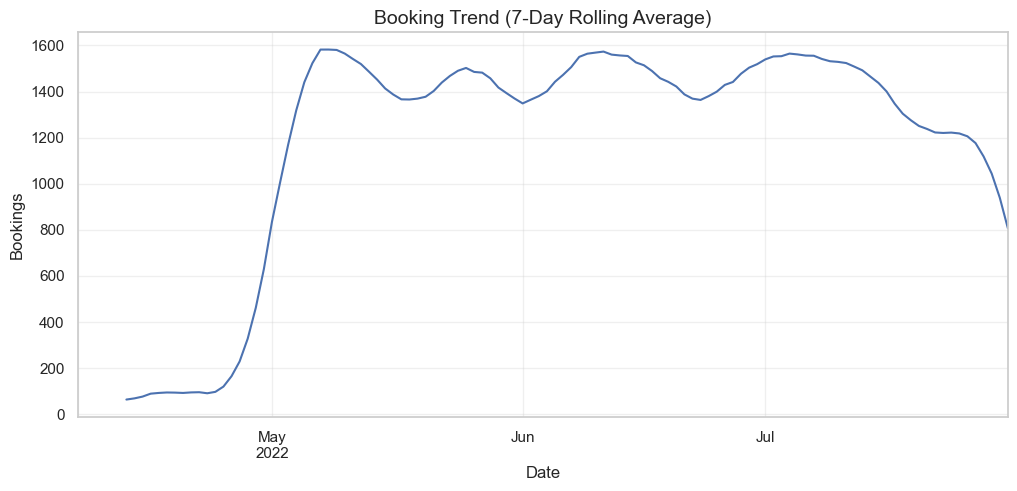

In [34]:
plt.figure(figsize=(12,5))

booking_trend.rolling(7).mean().plot()

plt.title("Booking Trend (7-Day Rolling Average)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Bookings")
plt.grid(alpha=0.3)

plt.show()

📊 Observation:  
Booking volumes show sharp fluctuations over time, with distinct spikes followed by steep declines. Peak periods (around mid-year) exhibit extremely high booking activity, while other periods reflect significantly lower and more stable demand.  

The 7-day rolling average smoothens short-term volatility and highlights a broader pattern of **rising demand followed by gradual normalization**, with a slight upward trend toward the later months.

💡 Insight:  
The pattern clearly indicates **strong seasonality and cyclical demand behavior** in bookings. High peaks align with peak travel periods such as holidays or vacation seasons, while troughs represent off-season demand.  

The repeated spike-and-drop pattern suggests demand is **predictable rather than random**, making it highly suitable for forecasting. Additionally, the gradual recovery toward the end signals potential demand build-up for upcoming peak periods.

🚀 Recommendation:  
Leverage these seasonal trends by aligning pricing, inventory, and marketing strategies with peak demand periods to maximize revenue. Introduce targeted promotions and discounts during low-demand phases to stabilize occupancy and reduce revenue volatility.  

Implement forecasting models to anticipate demand cycles in advance, enabling better resource allocation, staffing, and pricing optimization for sustained business performance.

### 📌 Insight 8: Ratings vs Revenue  

Understanding how customer ratings influence revenue realization helps evaluate the impact of customer satisfaction on financial performance.

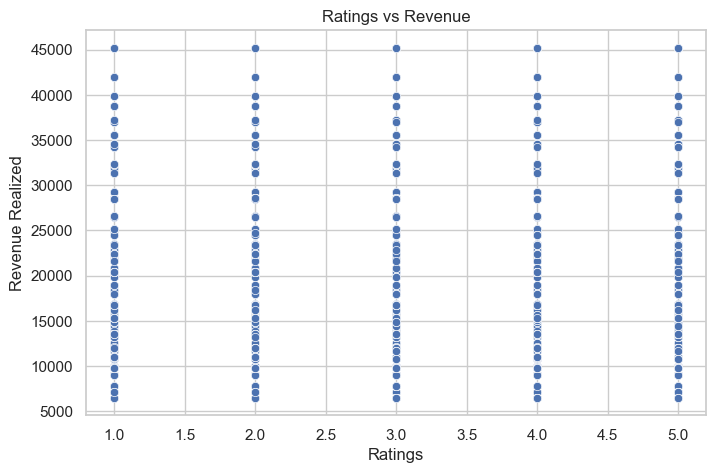

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='ratings_given',
    y='revenue_realized'
)

plt.title("Ratings vs Revenue")
plt.xlabel("Ratings")
plt.ylabel("Revenue Realized")

plt.show()

📊 Observation:  
The scatter plot shows revenue distributed across all rating levels (1 to 5), with no perfectly linear pattern. However, higher ratings (4 and 5) tend to have a slightly higher concentration of bookings with elevated revenue values compared to lower ratings.

💡 Insight:  
While the relationship is not strictly linear, there is a **weak positive correlation between ratings and revenue realization**. Higher-rated properties are more likely to generate better revenue, indicating that customer satisfaction plays a role in financial performance.  

However, the spread of revenue across all rating levels suggests that **factors like pricing, location, and booking platform also significantly influence revenue**, not just ratings alone.

🚀 Recommendation:  
Focus on improving customer experience to consistently achieve higher ratings, as this can enhance revenue potential over time. At the same time, combine this with optimized pricing strategies and better platform positioning to fully capitalize on revenue opportunities.  

Additionally, analyze low-rated but high-revenue cases to identify hidden drivers that can be replicated across properties.

### 📌 Insight 9: Cancellation Analysis  

Analyzing booking cancellations helps uncover revenue leakage patterns and identify platforms contributing to higher cancellation risk.

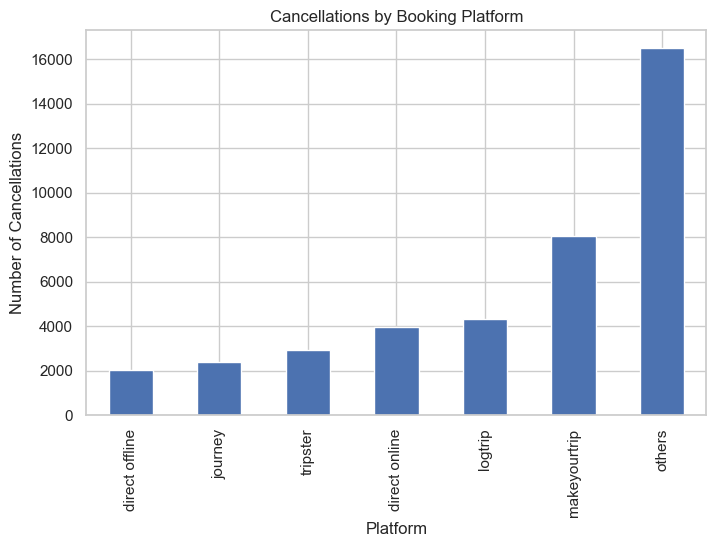

In [36]:
cancel_data = df[df['booking_status'] != 'Checked Out']

plt.figure(figsize=(8,5))

cancel_data.groupby('booking_platform')['booking_id'].count().sort_values().plot(kind='bar')

plt.title("Cancellations by Booking Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Cancellations")

plt.show()

📊 Observation:  
Cancellation volumes vary significantly across booking platforms, with **"others"** and **"makeyourtrip"** showing the highest number of cancellations by a large margin. In contrast, platforms like **"direct offline"** and **"journey"** exhibit relatively lower cancellation counts.

💡 Insight:  
The concentration of cancellations in a few platforms suggests **platform-driven booking behavior**, where certain channels attract more tentative or price-sensitive customers. High cancellations on platforms like **"others"** may indicate aggressive discounting, low booking commitment, or lack of strict cancellation policies.  

This pattern highlights a major source of **revenue leakage**, as a substantial portion of potential revenue fails to convert into realized bookings.

🚀 Recommendation:  
Implement stricter cancellation policies or partial prepayment requirements on high-cancellation platforms to improve booking commitment. Focus on optimizing pricing strategies to reduce speculative bookings and monitor platform-wise cancellation trends regularly.  

Additionally, strengthen **direct booking channels** with incentives to attract more reliable customers and reduce dependency on volatile third-party platforms.

## 📊 Insight 10: City vs Platform Revenue Heatmap

Analyzing how different booking platforms contribute to revenue across cities helps uncover regional performance patterns, platform dominance, and potential channel optimization opportunities.

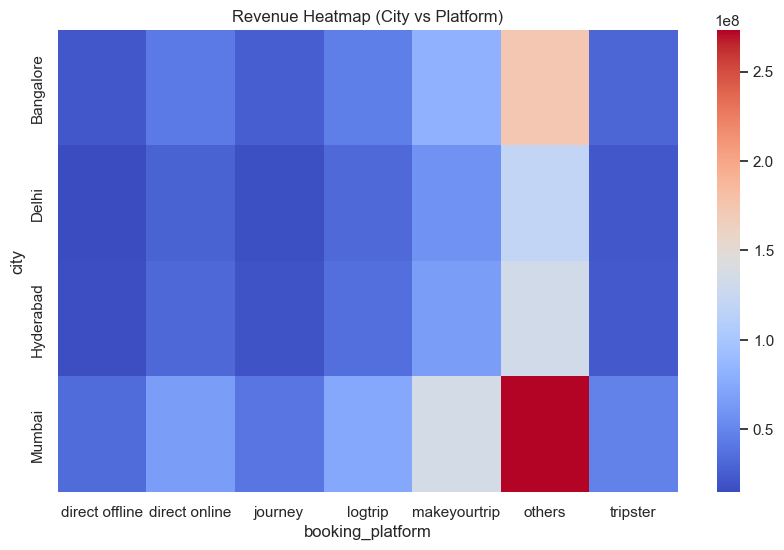

In [37]:
pivot = df.pivot_table(
    values='revenue_realized',
    index='city',
    columns='booking_platform',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(pivot, cmap='coolwarm', annot=False)

plt.title("Revenue Heatmap (City vs Platform)")

plt.show()

📊 Observation:  
The heatmap reveals that revenue distribution across booking platforms varies notably by city. Platforms like **"others"** and **"makeyourtrip"** show significantly higher revenue contributions, especially in cities like Mumbai and Bangalore, while platforms such as **"direct offline"** and **"tripster"** contribute comparatively less across most regions.

💡 Insight:  
This pattern indicates a strong dependence on a few dominant platforms for revenue generation, with **"others" emerging as a major revenue driver across multiple cities**. The variation across cities highlights that customer booking behavior is not uniform and is influenced by regional platform preferences and accessibility.  

Such concentration also signals a potential **risk of over-reliance on specific platforms**, which could impact revenue stability if platform dynamics change.

🚀 Recommendation:  
Capitalize on high-performing platforms like **"others"** and **"makeyourtrip"** by strengthening partnerships and optimizing visibility on these channels. Simultaneously, focus on improving performance of weaker platforms through targeted promotions, better pricing strategies, or enhanced user experience.  

Additionally, invest in **direct booking channels** to reduce dependency on third-party platforms and build a more balanced, resilient revenue mix.

## 💼 Business Recommendations

Based on the analysis, the following strategic recommendations can help improve revenue performance, reduce inefficiencies, and drive sustainable growth:

### 1. 🔻 Reduce Revenue Leakage  
- High cancellations and no-shows are significantly impacting realized revenue.  
- Implement stricter cancellation policies or introduce partial advance payments to secure bookings.  
- Use automated reminders and follow-ups to reduce no-show rates.  
- Analyze high-cancellation platforms and adjust pricing or policies accordingly.  

### 2. 📈 Optimize Weekday Revenue  
- Weekends consistently outperform weekdays, indicating demand imbalance.  
- Introduce targeted weekday discounts, corporate tie-ups, and business travel packages.  
- Promote mid-week staycation or work-from-hotel offers to boost occupancy.  
- Align marketing campaigns to attract weekday travelers and long-stay customers.  

### 3. 🏨 Strengthen High-Performing Segments  
- Premium and high-performing room classes/categories contribute disproportionately to revenue.  
- Enhance offerings, pricing strategies, and visibility for these segments.  
- Upsell customers through bundled services and personalized experiences.  

### 4. 🌍 Platform & City-Level Optimization  
- Different booking platforms perform differently across cities.  
- Focus marketing spend on top-performing platforms per city.  
- Reduce dependency on underperforming channels and strengthen direct bookings.  
- Leverage localized strategies based on regional customer behavior.  

### 5. ⭐ Improve Customer Experience & Ratings  
- Higher ratings correlate with better revenue realization.  
- Invest in service quality, staff training, and customer satisfaction initiatives.  
- Encourage reviews and feedback to build brand credibility.  
- Monitor low-rated properties and take corrective actions proactively.  

### 6. 📊 Leverage Seasonal Demand Patterns  
- Booking trends indicate strong seasonality and cyclical demand patterns.  
- Plan pricing, inventory, and marketing campaigns around peak seasons.  
- Introduce promotions during low-demand periods to maintain steady revenue flow.  
- Use forecasting models to anticipate demand and optimize resource allocation.

## 📌 Conclusion  

This analysis delivers a comprehensive, data-driven understanding of booking behavior, revenue dynamics, and customer preferences across AtliQ Hotels. By integrating multiple dimensions such as booking platforms, room classes, cities, time trends, and customer ratings, we uncover not just what is happening, but why it is happening.

The findings reveal that revenue generation is highly influenced by a combination of demand concentration, platform dependency, and seasonal fluctuations. A significant portion of revenue is driven by a limited set of high-performing room segments and premium offerings, indicating strong customer preference for value-driven experiences. At the same time, notable revenue leakage due to cancellations and no-shows highlights operational inefficiencies that directly impact profitability.

Temporal analysis shows clear cyclical demand patterns, with sharp spikes during peak travel periods and consistent dips during off-season windows. This predictable behavior suggests that demand is not random but structured, providing an opportunity for proactive planning through dynamic pricing, targeted campaigns, and inventory optimization.

Platform-level insights further reveal that different booking channels dominate in different cities, emphasizing the importance of localized strategies. Over-reliance on certain platforms may expose the business to higher cancellation risks or reduced margins, while underutilized channels represent untapped growth potential.

Additionally, the positive relationship between customer ratings and revenue reinforces the critical role of service quality and customer experience. Properties that consistently deliver better experiences are more likely to achieve higher revenue realization, making customer satisfaction a direct driver of financial performance.

Overall, this analysis highlights a clear roadmap for improving business performance. By reducing revenue leakage, optimizing pricing strategies, leveraging demand seasonality, strengthening direct booking channels, and enhancing customer experience, AtliQ Hotels can achieve more stable, predictable, and scalable growth.

Implementing these insights can lead to:
- Higher occupancy and improved revenue realization  
- Better operational efficiency and reduced losses  
- Stronger customer loyalty and brand positioning  
- Data-driven decision-making for long-term sustainability

## 🚀 Final Takeaways (Quick Summary)

- 💸 **Revenue Leakage is Significant**  
  A considerable portion of potential revenue is lost due to cancellations and no-shows, directly impacting realized income. This highlights the need for stricter cancellation policies, better booking commitment mechanisms, and proactive customer engagement to minimize last-minute drop-offs.

- 📅 **Weekend Demand Dominates**  
  Booking patterns consistently peak during weekends, driven largely by leisure travel demand. This creates a visible gap in weekday performance, suggesting an opportunity to introduce targeted weekday campaigns, corporate tie-ups, and promotional pricing strategies to balance demand.

- ⭐ **Customer Experience Drives Revenue**  
  A clear positive relationship exists between customer ratings and revenue realization. Properties delivering better experiences tend to perform financially stronger, reinforcing the importance of service quality, consistency, and customer satisfaction initiatives.

- 🌐 **Booking Platforms Matter**  
  Revenue is concentrated across a limited number of booking platforms, with performance varying significantly across cities. This indicates both dependency and opportunity—optimizing platform strategies and strengthening direct booking channels can improve margins and reduce risk.

- 📊 **Clear Demand Seasonality**  
  Booking trends follow a cyclical pattern with identifiable peaks and troughs, reflecting seasonal travel behavior. This predictability allows for better forecasting, dynamic pricing, and efficient inventory planning to maximize revenue during high-demand periods and sustain performance during low-demand phases.

---

🎯 **Final Thought:**  
By strategically reducing revenue leakage, optimizing demand across weekdays and platforms, enhancing customer experience, and leveraging seasonal patterns, the business can achieve more consistent revenue growth, improved operational efficiency, and a stronger competitive position in the market.